In [1]:
import keras 



In [2]:
keras.datasets.cifar10.load_data()


((array([[[[ 59,  62,  63],
           [ 43,  46,  45],
           [ 50,  48,  43],
           ...,
           [158, 132, 108],
           [152, 125, 102],
           [148, 124, 103]],
  
          [[ 16,  20,  20],
           [  0,   0,   0],
           [ 18,   8,   0],
           ...,
           [123,  88,  55],
           [119,  83,  50],
           [122,  87,  57]],
  
          [[ 25,  24,  21],
           [ 16,   7,   0],
           [ 49,  27,   8],
           ...,
           [118,  84,  50],
           [120,  84,  50],
           [109,  73,  42]],
  
          ...,
  
          [[208, 170,  96],
           [201, 153,  34],
           [198, 161,  26],
           ...,
           [160, 133,  70],
           [ 56,  31,   7],
           [ 53,  34,  20]],
  
          [[180, 139,  96],
           [173, 123,  42],
           [186, 144,  30],
           ...,
           [184, 148,  94],
           [ 97,  62,  34],
           [ 83,  53,  34]],
  
          [[177, 144, 116],
           [16

In [3]:
from keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(Flatten(input_shape=(32, 32, 3)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3145 - loss: 1.8958 - val_accuracy: 0.3501 - val_loss: 1.8278
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3850 - loss: 1.7171 - val_accuracy: 0.3835 - val_loss: 1.7164
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4078 - loss: 1.6560 - val_accuracy: 0.4168 - val_loss: 1.6486
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4240 - loss: 1.6155 - val_accuracy: 0.4223 - val_loss: 1.6376
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4362 - loss: 1.5759 - val_accuracy: 0.4121 - val_loss: 1.6585
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4473 - loss: 1.5483 - val_accuracy: 0.4252 - val_loss: 1.6111
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4563 - loss: 1.5169 - val_accuracy: 0.4330 - val_loss: 1.6044
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4628 - loss: 1.5021 - 

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - accuracy: 0.4815 - loss: 1.4791
Test Accuracy: 0.4814999997615814
Test Loss: 1.4790825843811035


In [11]:
import numpy as np
prediction=model.predict(X_test)
predicted_class=np.argmax(prediction[0])
actual_class=np.argmax(y_test[0])
classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
           'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("Predicted:", classes[predicted_class])
print("Actual:", classes[actual_class])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step
Predicted: Cat
Actual: Cat


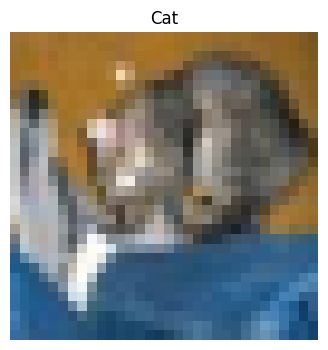

In [12]:
plt.figure(figsize=(4,4))
plt.imshow(X_test[0])
plt.title(classes[np.argmax(y_test[0])])
plt.axis("off")
plt.show()

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3529 - loss: 1.7380 - val_accuracy: 0.4924 - val_loss: 1.4015
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4905 - loss: 1.4061 - val_accuracy: 0.5568 - val_loss: 1.2514
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5483 - loss: 1.2665 - val_accuracy: 0.5977 - val_loss: 1.1367
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5888 - loss: 1.1585 - val_accuracy: 0.6267 - val_loss: 1.0648
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6226 - loss: 1.0734 - val_accuracy: 0.6248 - val_loss: 1.0794
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6505 - loss: 0.9985 - val_accuracy: 0.6759 - val_loss: 0.9417
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6717 - loss: 0.9416 - val_accuracy: 0.6795 - val_loss: 0.9343
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6909 - loss: 0.8886 - 

In [16]:
import numpy as np

prediction = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [17]:
predicted_class = np.argmax(prediction[4])
actual_class = np.argmax(y_test[4])
classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
           'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
print("Predicted Class:", classes[predicted_class])
print("Actual Class:", classes[actual_class])

Predicted Class: Frog
Actual Class: Frog


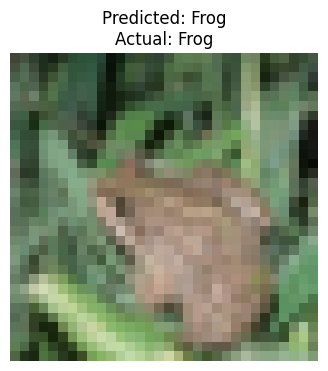

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.imshow(X_test[4])
plt.title(f"Predicted: {classes[predicted_class]}\nActual: {classes[actual_class]}")
plt.axis("off")
plt.show()

In [19]:
# Save the model to an HDF5 file
model.save("cifar10_cnn_model.h5")
print("Model saved successfully!")

Model saved successfully!
